# Tokenomics Analysis

This notebook analyzes the token economics of OSQ (Open Short-answer Question) responses.

Contextually, most responses were asked to keep outputs to 1-2 sentences, in some cases 3-4. The maximum allows in a response was 500 tokens for the lm-evaluation-harness.

## Analysis Goals

1. **Token Counting**: Measure input/output tokens for all OSQ responses
2. **Efficiency Metrics**: Calculate score-per-token ratios
3. **Cost Analysis**: Estimate computational costs based on token usage
4. **Quality Correlation**: Examine relationship between verbosity and quality
5. **Model Comparison**: Compare token efficiency across models

## Visualizations

1. Token distribution violin/box plots by model
2. Efficiency scatter plot matrix (tokens vs. quality)
3. Token budget heatmap
4. Cost-quality trade-off chart
5. Token length vs. score category analysis

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Tokenization
import tiktoken

# Progress bar
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Local parsers
import sys
from parsers import parse_osq_judged_samples, filter_osq_data, get_available_judges_and_prompts

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports complete")

✅ Imports complete


## Load OSQ Data

Using the same data loading approach as the main analysis notebook.

In [2]:
# Paths
phase5_dir = Path("../phase5_llm_as_a_judge")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Load OSQ judged samples
print("📂 Loading OSQ judged samples...\n")
osq_data = parse_osq_judged_samples(phase5_dir)
osq_df = pd.DataFrame(osq_data)

print(f"\n✅ OSQ DataFrame shape: {osq_df.shape}")

if len(osq_df) > 0:
    print(f"   Models: {osq_df['model'].unique().tolist()}")
    print(f"   Questions: {osq_df['question_id'].nunique()}")
    print(f"   Mean score: {osq_df['total_score'].mean():.2f}")
    
    # Show available judges and prompts
    available = get_available_judges_and_prompts(osq_data)
    print(f"\n   Judges: {available['judges']}")
    print(f"   Prompts: {available['prompts']}")
else:
    print("⚠️  No OSQ data found!")

📂 Loading OSQ judged samples...

📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__gpt-oss_120b-p1.jsonl (judge: gpt-oss_120b, prompt: p1)
   ⚠️  Error processing line 107: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 110: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 111: unsupported operand type(s) for +: 'NoneType' and 'NoneType'
   ⚠️  Error processing line 748: 'NoneType' object has no attribute 'get'
📖 Parsing devstral__24b/samples_sysengbench-osq_2025-11-19T22-36-33.281032__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
   ⚠️  Error processing line 207: 'NoneType' object has no attribute 'get'
📖 Parsing gemma3__12b/samples_sysengbench-osq_2025-11-19T22-23-32.102126__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
   ⚠️  Error processing line 501: 'NoneType' object has no attribute 'get'
📖 Parsing gemma3__1b/samples

## Filter OSQ Data (Optional)

You can filter by specific judge model and prompt ID if needed.

In [5]:
# Option 1: Use all data
osq_df_filtered = osq_df.copy()

# Option 2: Filter by specific judge and prompt (uncomment to use)
# JUDGE_MODEL = 'openai_gpt-4o-mini'  # Change as needed
# PROMPT_ID = 'p1'  # Change as needed
# osq_data_filtered = filter_osq_data(osq_data, judge_model=JUDGE_MODEL, prompt_id=PROMPT_ID)
# osq_df_filtered = pd.DataFrame(osq_data_filtered)
# print(f"Filtered to {len(osq_df_filtered)} samples (judge={JUDGE_MODEL}, prompt={PROMPT_ID})")

print(f"Working with {len(osq_df_filtered)} OSQ samples")

Working with 16017 OSQ samples


## Token Counting

Use tiktoken (GPT tokenizer) as a standard reference for counting tokens.

In [3]:
def count_tokens(text: str, encoding_name: str = "cl100k_base") -> int:
    """
    Count tokens in text using tiktoken.
    
    Args:
        text: Text to tokenize
        encoding_name: Tokenizer encoding (cl100k_base = GPT-4, GPT-3.5-turbo)
    
    Returns:
        Number of tokens
    """
    if pd.isna(text) or text == '':
        return 0
    
    try:
        encoding = tiktoken.get_encoding(encoding_name)
        return len(encoding.encode(str(text)))
    except Exception as e:
        print(f"Warning: Error counting tokens: {e}")
        return 0

# Test the function
test_text = "Systems engineering is an interdisciplinary field."
test_tokens = count_tokens(test_text)
print(f"Test: '{test_text}'")
print(f"Token count: {test_tokens}")

Test: 'Systems engineering is an interdisciplinary field.'
Token count: 7


In [6]:
# Add token counts to dataframe
print("🔢 Counting tokens...\n")

tqdm.pandas(desc="Prompt tokens")
osq_df_filtered['prompt_tokens'] = osq_df_filtered['osq_prompt'].progress_apply(count_tokens)

tqdm.pandas(desc="Response tokens")
osq_df_filtered['response_tokens'] = osq_df_filtered['model_response'].progress_apply(count_tokens)

tqdm.pandas(desc="Expected answer tokens")
osq_df_filtered['expected_tokens'] = osq_df_filtered['expected_answer'].progress_apply(count_tokens)

# Calculate total tokens (input + output)
osq_df_filtered['total_tokens'] = osq_df_filtered['prompt_tokens'] + osq_df_filtered['response_tokens']

# Calculate efficiency metric: score per token
osq_df_filtered['score_per_token'] = osq_df_filtered.apply(
    lambda row: row['total_score'] / row['response_tokens'] if row['response_tokens'] > 0 else 0,
    axis=1
)

# Calculate tokens per score point (inverse efficiency)
osq_df_filtered['tokens_per_point'] = osq_df_filtered.apply(
    lambda row: row['response_tokens'] / row['total_score'] if row['total_score'] > 0 else np.inf,
    axis=1
)

print("\n✅ Token counting complete")
print(f"\nToken statistics:")
print(osq_df_filtered[['prompt_tokens', 'response_tokens', 'expected_tokens', 'total_tokens']].describe())

🔢 Counting tokens...



Prompt tokens:   0%|          | 0/16017 [00:00<?, ?it/s]

Response tokens:   0%|          | 0/16017 [00:00<?, ?it/s]

Expected answer tokens:   0%|          | 0/16017 [00:00<?, ?it/s]


✅ Token counting complete

Token statistics:
       prompt_tokens  response_tokens  expected_tokens  total_tokens
count   16017.000000     16017.000000     16017.000000  16017.000000
mean       30.005931        56.756384        20.324031     86.762315
std         8.489395        31.232119        12.358768     31.871245
min        13.000000         1.000000         1.000000     21.000000
25%        24.000000        41.000000        10.000000     68.000000
50%        29.000000        60.000000        21.000000     88.000000
75%        34.000000        75.000000        28.000000    104.000000
max        75.000000       504.000000        88.000000    552.000000


## Token Statistics by Model

In [7]:
# Aggregate token statistics by model
token_stats_by_model = osq_df_filtered.groupby('model').agg({
    'response_tokens': ['mean', 'median', 'std', 'min', 'max'],
    'total_tokens': ['mean', 'median', 'std', 'min', 'max'],
    'total_score': ['mean', 'median'],
    'score_per_token': ['mean', 'median'],
    'tokens_per_point': ['mean', 'median'],
    'question_id': 'count'
}).round(2)

# Flatten column names
token_stats_by_model.columns = ['_'.join(col).strip() for col in token_stats_by_model.columns.values]
token_stats_by_model = token_stats_by_model.rename(columns={'question_id_count': 'n_samples'})

# Sort by efficiency (highest score per token)
token_stats_by_model = token_stats_by_model.sort_values('score_per_token_mean', ascending=False)

print("Token Statistics by Model:")
print(token_stats_by_model)

# Save to CSV
token_stats_by_model.to_csv(output_dir / 'token_stats_by_model.csv')
print(f"\n✅ Saved to {output_dir / 'token_stats_by_model.csv'}")

Token Statistics by Model:
                              response_tokens_mean  response_tokens_median  \
model                                                                        
google__gemini-2.5-flash                     43.98                    49.0   
openai__gpt-4.1                              46.63                    55.0   
mistral-large__123b                          49.69                    56.0   
mistral-small3.2__24b                        45.05                    51.0   
anthropic__claude-sonnet-4.5                 48.61                    54.0   
llama3.3__70b                                56.48                    65.0   
llama4__16x17b                               46.64                    52.0   
mixtral__8x22b                               45.16                    48.0   
devstral__24b                                45.47                    48.0   
gemma3__12b                                  63.85                    73.0   
llama3.2__3b                         

## Visualization 1: Token Distribution by Model

Violin plots showing response token distributions with quality score overlays.

Score currently assumes gpt-5-mini.

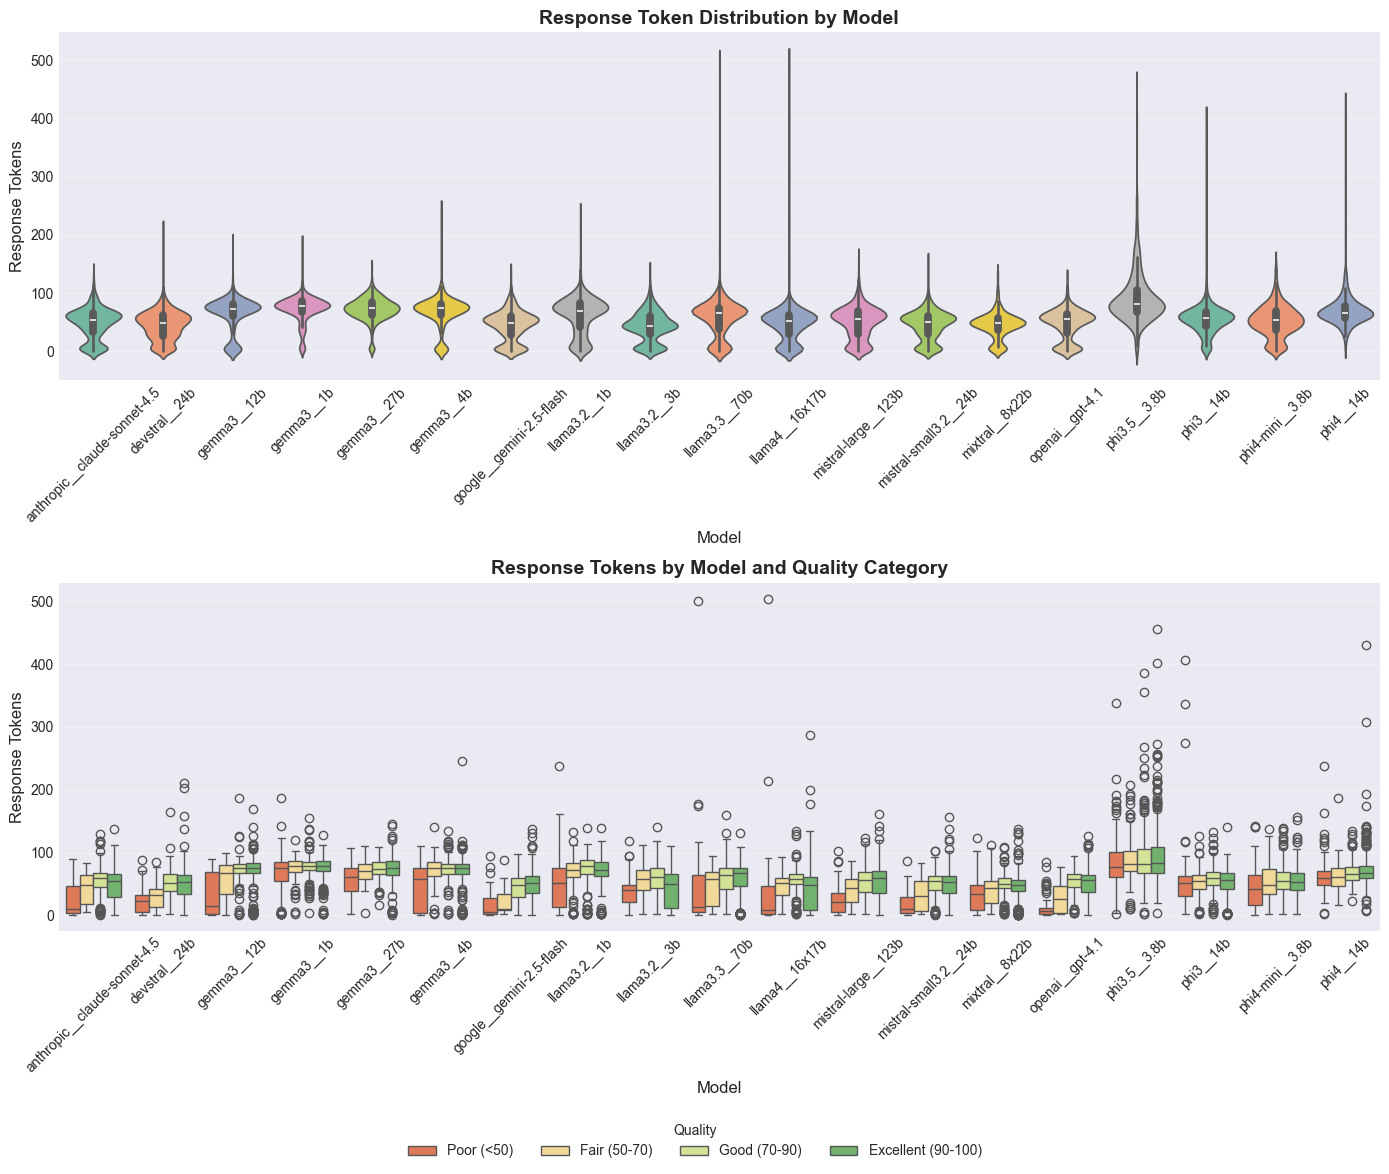

✅ Saved to output\tokenomics_distribution.png


In [22]:
# Create quality score categories
osq_df_filtered['quality_category'] = pd.cut(
    osq_df_filtered['total_score'],
    bins=[0, 50, 70, 90, 100],
    labels=['Poor (<50)', 'Fair (50-70)', 'Good (70-90)', 'Excellent (90-100)']
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))  # taller for bottom legend

# Violin plot
ax1 = axes[0]
sns.violinplot(
    data=osq_df_filtered,
    x='model',
    y='response_tokens',
    ax=ax1,
    palette='Set2'
)
ax1.set_title('Response Token Distribution by Model', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Response Tokens', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Box plot with quality categories
ax2 = axes[1]
sns.boxplot(
    data=osq_df_filtered,
    x='model',
    y='response_tokens',
    hue='quality_category',
    ax=ax2,
    palette='RdYlGn'
)
ax2.set_title('Response Tokens by Model and Quality Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Response Tokens', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Remove axis-level legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend_.remove()

# Add bottom-centered legend for the whole figure
fig.legend(
    handles,
    labels,
    title="Quality",
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.02),  # adjust spacing below
    frameon=False
)

# Adjust spacing so legend is visible
plt.tight_layout(rect=[0, 0.07, 1, 1])  # make room for bottom legend

plt.savefig(output_dir / 'tokenomics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {output_dir / 'tokenomics_distribution.png'}")


## Visualization 2: Efficiency Scatter Plot Matrix

Scatter plots showing the relationship between token usage and quality scores.

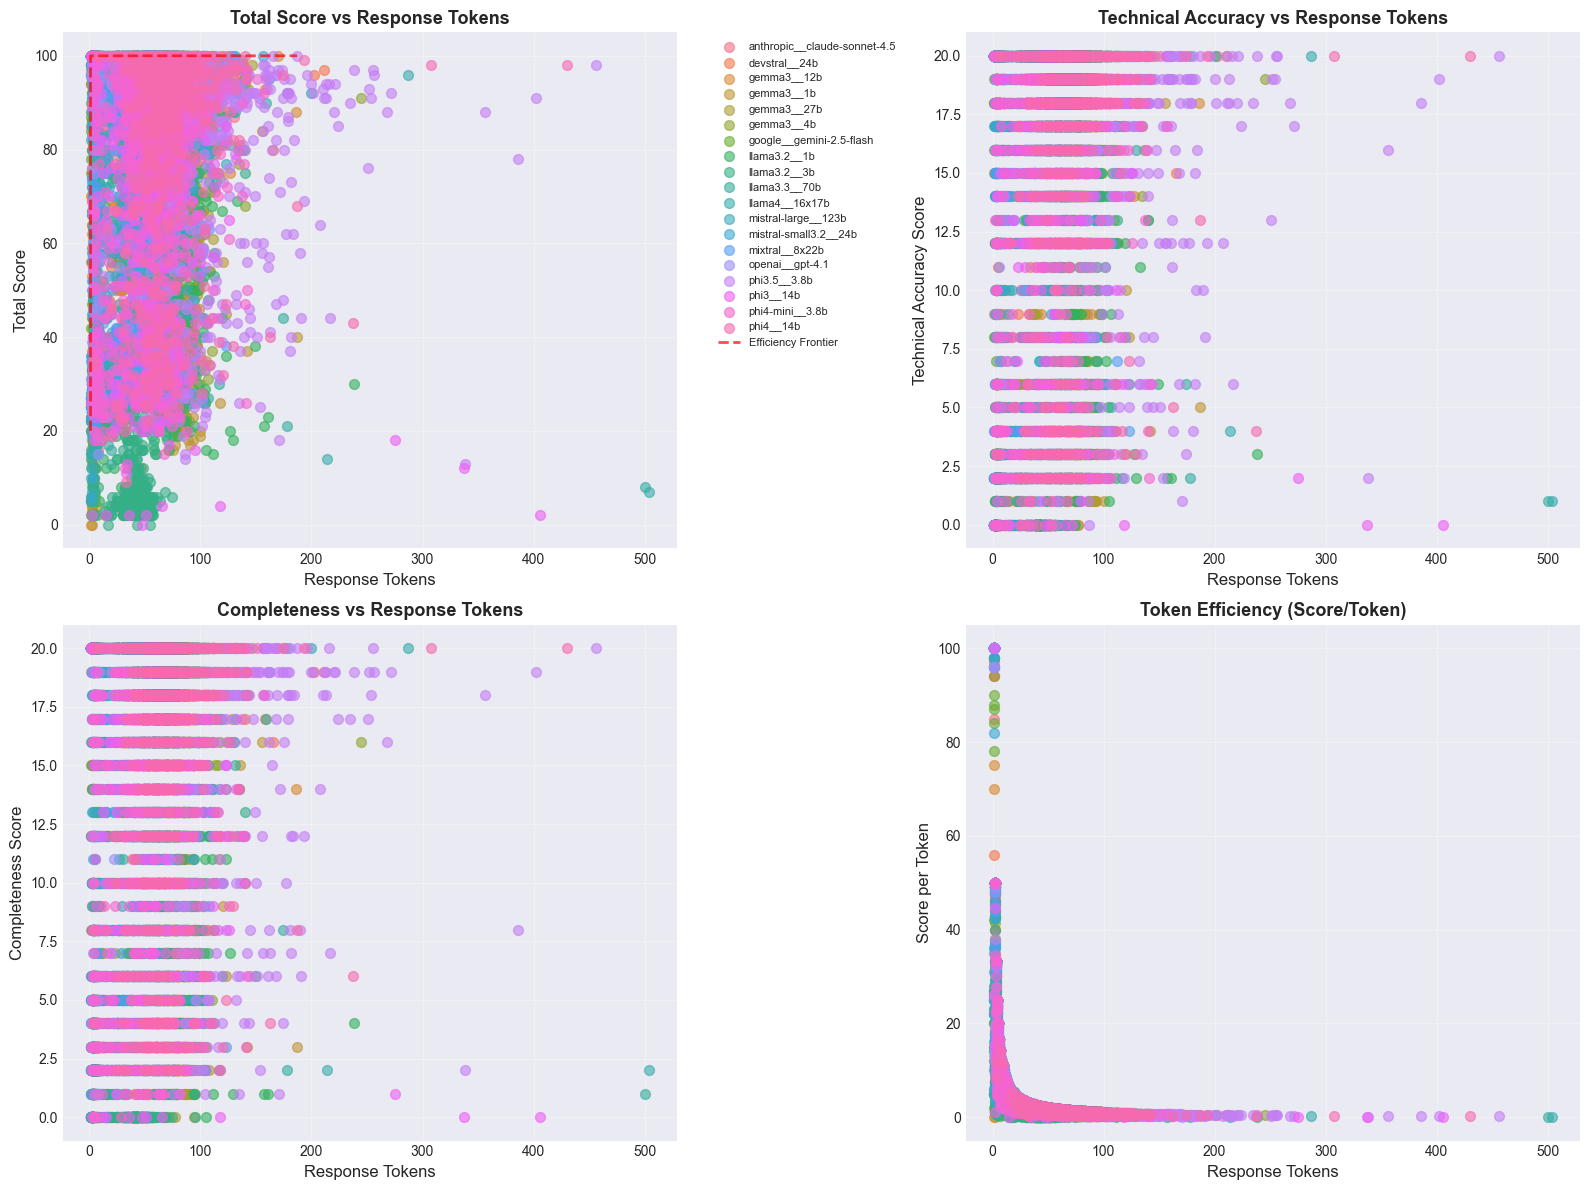

✅ Saved to output\tokenomics_efficiency_scatter.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = osq_df_filtered['model'].unique()
colors = sns.color_palette('husl', n_colors=len(models))
model_colors = dict(zip(models, colors))

# Plot 1: Total Score vs Response Tokens
ax1 = axes[0, 0]
for model in models:
    model_data = osq_df_filtered[osq_df_filtered['model'] == model]
    ax1.scatter(
        model_data['response_tokens'],
        model_data['total_score'],
        alpha=0.6,
        label=model,
        color=model_colors[model],
        s=50
    )

# Add efficiency frontier (Pareto front approximation)
# Find points with high score and low tokens
sorted_by_tokens = osq_df_filtered.sort_values('response_tokens')
frontier_score = sorted_by_tokens['total_score'].expanding().max()
frontier_points = sorted_by_tokens[sorted_by_tokens['total_score'] == frontier_score]
ax1.plot(
    frontier_points['response_tokens'],
    frontier_points['total_score'],
    'r--',
    linewidth=2,
    alpha=0.7,
    label='Efficiency Frontier'
)

ax1.set_xlabel('Response Tokens', fontsize=12)
ax1.set_ylabel('Total Score', fontsize=12)
ax1.set_title('Total Score vs Response Tokens', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 2: Technical Accuracy vs Response Tokens
ax2 = axes[0, 1]
for model in models:
    model_data = osq_df_filtered[osq_df_filtered['model'] == model]
    ax2.scatter(
        model_data['response_tokens'],
        model_data['technical_accuracy'],
        alpha=0.6,
        color=model_colors[model],
        s=50
    )
ax2.set_xlabel('Response Tokens', fontsize=12)
ax2.set_ylabel('Technical Accuracy Score', fontsize=12)
ax2.set_title('Technical Accuracy vs Response Tokens', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# Plot 3: Completeness vs Response Tokens
ax3 = axes[1, 0]
for model in models:
    model_data = osq_df_filtered[osq_df_filtered['model'] == model]
    ax3.scatter(
        model_data['response_tokens'],
        model_data['completeness'],
        alpha=0.6,
        color=model_colors[model],
        s=50
    )
ax3.set_xlabel('Response Tokens', fontsize=12)
ax3.set_ylabel('Completeness Score', fontsize=12)
ax3.set_title('Completeness vs Response Tokens', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)

# Plot 4: Score per Token (Efficiency)
ax4 = axes[1, 1]
for model in models:
    model_data = osq_df_filtered[osq_df_filtered['model'] == model]
    ax4.scatter(
        model_data['response_tokens'],
        model_data['score_per_token'],
        alpha=0.6,
        color=model_colors[model],
        s=50
    )
ax4.set_xlabel('Response Tokens', fontsize=12)
ax4.set_ylabel('Score per Token', fontsize=12)
ax4.set_title('Token Efficiency (Score/Token)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'tokenomics_efficiency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {output_dir / 'tokenomics_efficiency_scatter.png'}")

## Visualization 3: Token Budget Heatmap

Heatmap comparing token metrics across models.

In [11]:
# Prepare data for heatmap
heatmap_data = osq_df_filtered.groupby('model').agg({
    'prompt_tokens': 'mean',
    'response_tokens': 'mean',
    'total_tokens': 'mean',
    'total_score': 'mean',
    'score_per_token': 'mean',
    'tokens_per_point': 'mean'
}).round(2)

# Rename columns for better display
heatmap_data.columns = [
    'Avg Prompt\nTokens',
    'Avg Response\nTokens',
    'Avg Total\nTokens',
    'Avg Quality\nScore',
    'Score per\nToken',
    'Tokens per\nScore Point'
]

# Normalize each column for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap 1: Actual values
ax1 = axes[0]
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax1,
    cbar_kws={'label': 'Value'},
    linewidths=0.5
)
ax1.set_title('Token Metrics by Model (Actual Values)', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Model', fontsize=12)

# Heatmap 2: Normalized values (z-scores)
ax2 = axes[1]
sns.heatmap(
    heatmap_normalized,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax2,
    cbar_kws={'label': 'Z-score'},
    linewidths=0.5
)
ax2.set_title('Token Metrics by Model (Normalized Z-scores)', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig(output_dir / 'tokenomics_budget_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {output_dir / 'tokenomics_budget_heatmap.png'}")

ValueError: Input X contains infinity or a value too large for dtype('float64').

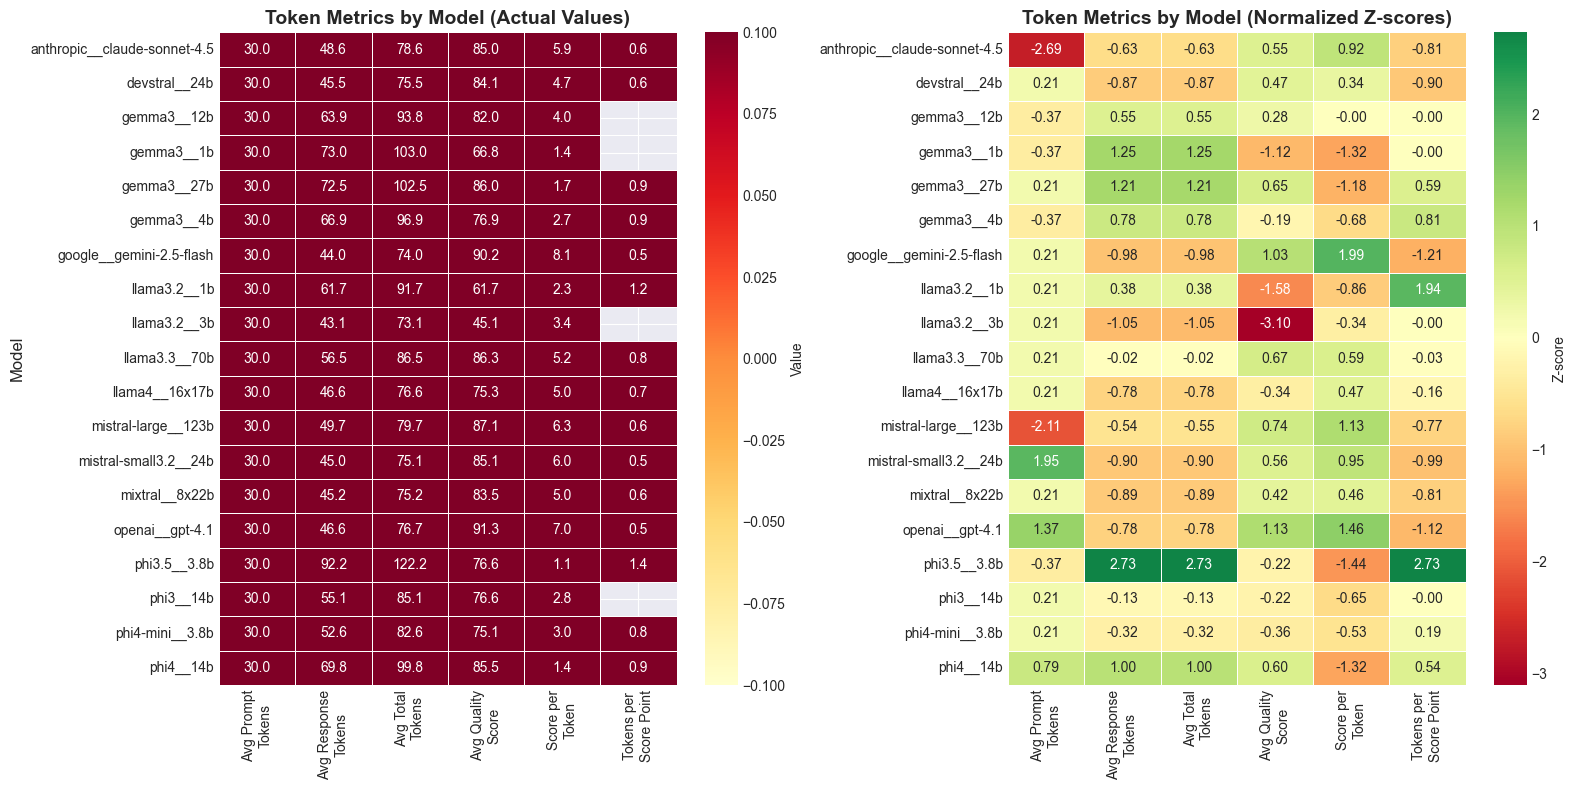

✅ Saved to output\tokenomics_budget_heatmap.png


In [15]:
# Prepare data for heatmap
heatmap_data = osq_df_filtered.groupby('model').agg({
    'prompt_tokens': 'mean',
    'response_tokens': 'mean',
    'total_tokens': 'mean',
    'total_score': 'mean',
    'score_per_token': 'mean',
    'tokens_per_point': 'mean'
}).round(2)

# Rename columns for better display
heatmap_data.columns = [
    'Avg Prompt\nTokens',
    'Avg Response\nTokens',
    'Avg Total\nTokens',
    'Avg Quality\nScore',
    'Score per\nToken',
    'Tokens per\nScore Point'
]

# -----------------------------------------------------------
# HARD CLEANING: remove inf, nan, and overly large values
# -----------------------------------------------------------

# Replace +/-inf → NaN
heatmap_data_clean = heatmap_data.replace([np.inf, -np.inf], np.nan)

# Replace NaN → column means
heatmap_data_clean = heatmap_data_clean.fillna(heatmap_data_clean.mean())

# Cap extreme outliers to prevent float64 overflow in scaler
# (Values above 1e12 cause sklearn to choke)
heatmap_data_clean = heatmap_data_clean.clip(lower=-1e12, upper=1e12)

# -----------------------------------------------------------
# Normalization
# -----------------------------------------------------------

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data_clean),
    index=heatmap_data_clean.index,
    columns=heatmap_data_clean.columns
)

# -----------------------------------------------------------
# Plotting
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap 1: Actual values
ax1 = axes[0]
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax1,
    cbar_kws={'label': 'Value'},
    linewidths=0.5
)
ax1.set_title('Token Metrics by Model (Actual Values)', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Model', fontsize=12)

# Heatmap 2: Normalized values (z-scores)
ax2 = axes[1]
sns.heatmap(
    heatmap_normalized,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax2,
    cbar_kws={'label': 'Z-score'},
    linewidths=0.5
)
ax2.set_title('Token Metrics by Model (Normalized Z-scores)', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')

plt.tight_layout()

save_path = output_dir / 'tokenomics_budget_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {save_path}")


## Visualization 4: Cost-Quality Trade-off Chart

Analyze cost-effectiveness using hypothetical pricing.

**Note**: Using OpenAI GPT-4o pricing as reference:
- Input: $2.50 per 1M tokens
- Output: $10.00 per 1M tokens

## Model-Specific API Pricing

**Pricing Data Sources (as of December 2025):**

- **Anthropic**: [Claude API Pricing](https://docs.anthropic.com/en/docs/about-claude/pricing)
- **Google**: [Gemini API Pricing](https://ai.google.dev/gemini-api/docs/pricing)
- **OpenAI**: [OpenAI API Pricing](https://openai.com/api/pricing/)
- **Mistral AI**: [Mistral API Pricing](https://mistral.ai/pricing)
- **Open-source models**: Pricing via OpenRouter, Together AI, and Azure AI

**Notes:**
- Open-source models (Llama, Gemma, Phi, Mixtral) use typical API provider pricing (OpenRouter/Together AI/Azure)
- Prices are in USD per 1 million tokens
- For models with varying provider pricing, conservative estimates are used

In [ ]:
# Model-specific pricing dictionary ($/1M tokens)
# Pricing collected from official API docs and provider pages (December 2025)

MODEL_PRICING = {
    # Commercial Models - Direct API Pricing
    'anthropic__claude-sonnet-4.5': {
        'input': 3.00,
        'output': 15.00,
        'source': 'Anthropic API'
    },
    'google__gemini-2.5-flash': {
        'input': 0.30,
        'output': 2.50,
        'source': 'Google AI API'
    },
    'openai__gpt-4.1': {
        'input': 2.00,
        'output': 8.00,
        'source': 'OpenAI API'
    },
    'mistral-large__123b': {
        'input': 3.00,
        'output': 9.00,
        'source': 'Mistral AI API'
    },
    'mistral-small3.2__24b': {
        'input': 0.06,
        'output': 0.18,
        'source': 'Mistral AI API'
    },
    
    # Open-source Models - OpenRouter/Together AI pricing
    'llama3.2__1b': {
        'input': 0.02,
        'output': 0.02,
        'source': 'OpenRouter (estimated)'
    },
    'llama3.2__3b': {
        'input': 0.018,
        'output': 0.018,
        'source': 'OpenRouter'
    },
    'llama3.3__70b': {
        'input': 0.10,
        'output': 0.40,
        'source': 'Together AI'
    },
    'llama4__16x17b': {
        'input': 0.22,
        'output': 0.85,
        'source': 'Together AI (Maverick)'
    },
    'mixtral__8x22b': {
        'input': 2.00,
        'output': 6.00,
        'source': 'OpenRouter'
    },
    'gemma3__1b': {
        'input': 0.01,
        'output': 0.01,
        'source': 'OpenRouter (free tier proxy)'
    },
    'gemma3__4b': {
        'input': 0.01703,
        'output': 0.06815,
        'source': 'OpenRouter'
    },
    'gemma3__12b': {
        'input': 0.03,
        'output': 0.10,
        'source': 'OpenRouter'
    },
    'gemma3__27b': {
        'input': 0.07,
        'output': 0.50,
        'source': 'OpenRouter'
    },
    'phi3.5__3.8b': {
        'input': 0.10,
        'output': 0.10,
        'source': 'Azure AI'
    },
    'phi3__14b': {
        'input': 1.00,
        'output': 1.00,
        'source': 'Azure AI'
    },
    'phi4-mini__3.8b': {
        'input': 0.05,
        'output': 0.10,
        'source': 'Azure AI (Multimodal)'
    },
    'phi4__14b': {
        'input': 0.07,
        'output': 0.14,
        'source': 'Azure AI'
    },
    'devstral__24b': {
        'input': 0.10,
        'output': 0.30,
        'source': 'Mistral AI API'
    },
}

# Display pricing table
pricing_df = pd.DataFrame([
    {
        'Model': model,
        'Input ($/1M)': data['input'],
        'Output ($/1M)': data['output'],
        'Source': data['source']
    }
    for model, data in MODEL_PRICING.items()
]).sort_values('Input ($/1M)')

print("Model API Pricing (December 2025)")
print("=" * 80)
print(pricing_df.to_string(index=False))
print("\n" + "=" * 80)

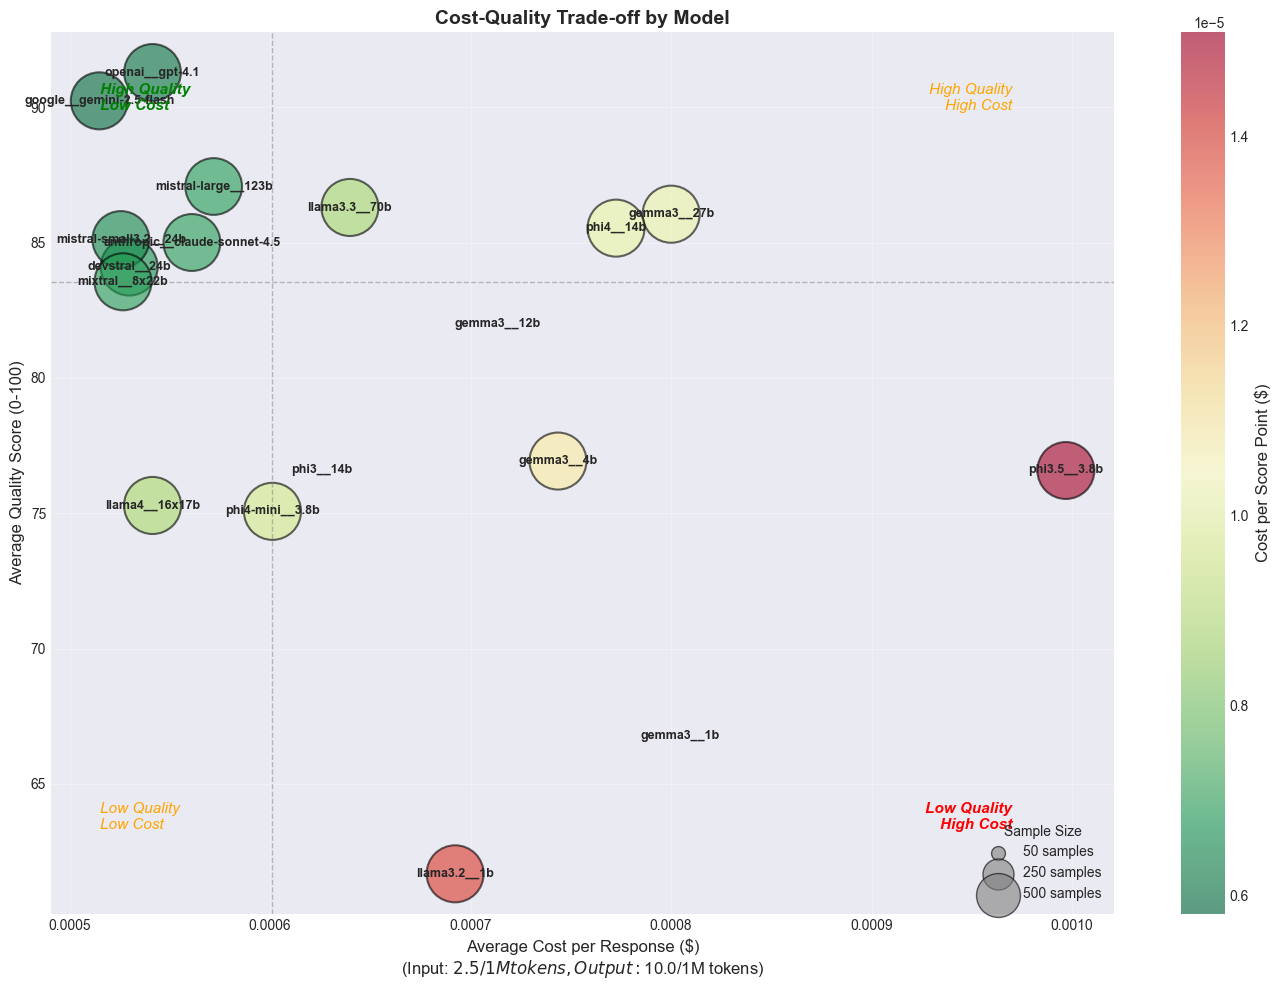

✅ Saved to output\tokenomics_cost_quality.png

Cost-Quality Summary:
                           model  avg_cost  avg_score  cost_per_point  \
6       google__gemini-2.5-flash  0.000515  90.240237        0.000006   
14               openai__gpt-4.1  0.000541  91.291517        0.000006   
12         mistral-small3.2__24b  0.000526  85.115339        0.000006   
1                  devstral__24b  0.000530  84.099526        0.000007   
11           mistral-large__123b  0.000572  87.075359        0.000007   
13                mixtral__8x22b  0.000527  83.554502        0.000007   
0   anthropic__claude-sonnet-4.5  0.000561  85.005945        0.000007   
9                  llama3.3__70b  0.000640  86.300592        0.000009   
10                llama4__16x17b  0.000541  75.288757        0.000009   
17               phi4-mini__3.8b  0.000601  75.072189        0.000009   
18                     phi4__14b  0.000773  85.536817        0.000010   
4                    gemma3__27b  0.000800  86.052071  

In [12]:
# Calculate model-specific costs using MODEL_PRICING dictionarydef get_model_pricing(model_name):    """Get pricing for a model, with fallback to average pricing if not found."""    if model_name in MODEL_PRICING:        return MODEL_PRICING[model_name]    else:        # Fallback: use average pricing across all models        avg_input = sum(p['input'] for p in MODEL_PRICING.values()) / len(MODEL_PRICING)        avg_output = sum(p['output'] for p in MODEL_PRICING.values()) / len(MODEL_PRICING)        print(f"⚠️  Warning: No pricing found for {model_name}, using average pricing")        return {'input': avg_input, 'output': avg_output, 'source': 'Average (fallback)'}# Apply model-specific pricing to each rowprint("💰 Calculating model-specific costs...\n")def calculate_costs(row):    pricing = get_model_pricing(row['model'])    input_cost = row['prompt_tokens'] * (pricing['input'] / 1_000_000)    output_cost = row['response_tokens'] * (pricing['output'] / 1_000_000)    total_cost = input_cost + output_cost    return pd.Series({        'input_cost': input_cost,        'output_cost': output_cost,        'total_cost': total_cost    })# Apply cost calculationcost_cols = osq_df_filtered.apply(calculate_costs, axis=1)osq_df_filtered[['input_cost', 'output_cost', 'total_cost']] = cost_cols# Calculate cost per score pointosq_df_filtered['cost_per_point'] = osq_df_filtered.apply(    lambda row: row['total_cost'] / row['total_score'] if row['total_score'] > 0 else np.inf,    axis=1)print("✅ Cost calculation complete\n")# Aggregate by modelcost_quality_by_model = osq_df_filtered.groupby('model').agg({    'total_cost': 'mean',    'total_score': 'mean',    'cost_per_point': 'mean',    'question_id': 'count'}).reset_index()cost_quality_by_model.columns = ['model', 'avg_cost', 'avg_score', 'cost_per_point', 'n_samples']# Add pricing info to the summarycost_quality_by_model['input_price'] = cost_quality_by_model['model'].apply(    lambda m: get_model_pricing(m)['input'])cost_quality_by_model['output_price'] = cost_quality_by_model['model'].apply(    lambda m: get_model_pricing(m)['output'])# Create bubble chartfig, ax = plt.subplots(figsize=(16, 12))scatter = ax.scatter(    cost_quality_by_model['avg_cost'],    cost_quality_by_model['avg_score'],    s=cost_quality_by_model['n_samples'] * 2,  # Bubble size = number of samples    c=cost_quality_by_model['cost_per_point'],    cmap='RdYlGn_r',    alpha=0.6,    edgecolors='black',    linewidth=1.5)# Add model labelsfor idx, row in cost_quality_by_model.iterrows():    ax.annotate(        row['model'],        (row['avg_cost'], row['avg_score']),        fontsize=8,        ha='center',        va='center',        fontweight='bold'    )# Add quadrant linesmedian_cost = cost_quality_by_model['avg_cost'].median()median_score = cost_quality_by_model['avg_score'].median()ax.axvline(median_cost, color='gray', linestyle='--', alpha=0.5, linewidth=1)ax.axhline(median_score, color='gray', linestyle='--', alpha=0.5, linewidth=1)# Add quadrant labelsax.text(ax.get_xlim()[0] * 1.05, ax.get_ylim()[1] * 0.98, 'High Quality\nLow Cost',         fontsize=11, ha='left', va='top', style='italic', color='green', fontweight='bold')ax.text(ax.get_xlim()[1] * 0.95, ax.get_ylim()[1] * 0.98, 'High Quality\nHigh Cost',         fontsize=11, ha='right', va='top', style='italic', color='orange')ax.text(ax.get_xlim()[0] * 1.05, ax.get_ylim()[0] * 1.05, 'Low Quality\nLow Cost',         fontsize=11, ha='left', va='bottom', style='italic', color='orange')ax.text(ax.get_xlim()[1] * 0.95, ax.get_ylim()[0] * 1.05, 'Low Quality\nHigh Cost',         fontsize=11, ha='right', va='bottom', style='italic', color='red', fontweight='bold')# Colorbarcbar = plt.colorbar(scatter, ax=ax)cbar.set_label('Cost per Score Point ($)', fontsize=12)ax.set_xlabel('Average Cost per Response ($)\n(Using model-specific API pricing)', fontsize=12)ax.set_ylabel('Average Quality Score (0-100)', fontsize=12)ax.set_title('Cost-Quality Trade-off by Model (Model-Specific Pricing)', fontsize=14, fontweight='bold')ax.grid(alpha=0.3)# Add legend for bubble sizehandles, labels = ax.get_legend_handles_labels()size_legend = ax.legend(    handles=[plt.scatter([], [], s=100, c='gray', alpha=0.6, edgecolors='black'),             plt.scatter([], [], s=500, c='gray', alpha=0.6, edgecolors='black'),             plt.scatter([], [], s=1000, c='gray', alpha=0.6, edgecolors='black')],    labels=['50 samples', '250 samples', '500 samples'],    title='Sample Size',    loc='lower right',    fontsize=10)plt.tight_layout()plt.savefig(output_dir / 'tokenomics_cost_quality.png', dpi=300, bbox_inches='tight')plt.show()print(f"✅ Saved to {output_dir / 'tokenomics_cost_quality.png'}")print("\nCost-Quality Summary (sorted by cost-effectiveness):")print("=" * 100)summary_display = cost_quality_by_model[[    'model', 'input_price', 'output_price', 'avg_cost', 'avg_score', 'cost_per_point']].sort_values('cost_per_point')summary_display.columns = ['Model', 'Input $/1M', 'Output $/1M', 'Avg Cost', 'Avg Score', '$/Point']print(summary_display.to_string(index=False))print("=" * 100)

## Visualization 5: Token Length vs Score Category

Stacked bar chart showing quality distribution across token length bins.

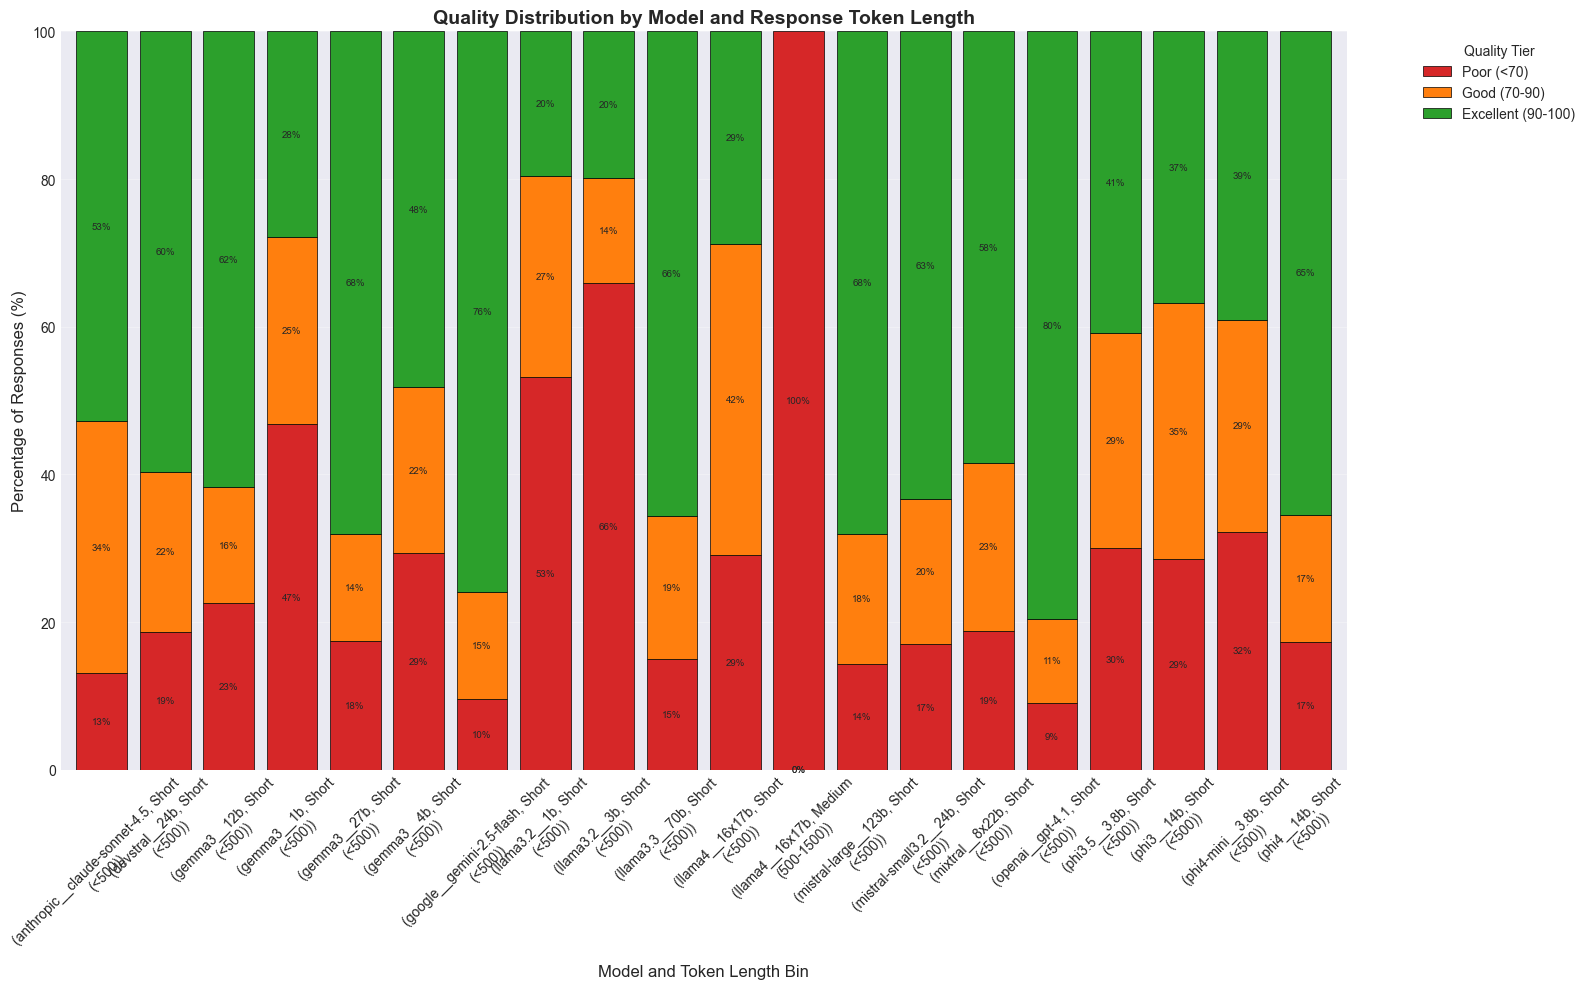

✅ Saved to output\tokenomics_length_vs_quality.png


In [14]:
# Create token length bins
osq_df_filtered['token_length_bin'] = pd.cut(
    osq_df_filtered['response_tokens'],
    bins=[0, 500, 1500, 3000, np.inf],
    labels=['Short\n(<500)', 'Medium\n(500-1500)', 'Long\n(1500-3000)', 'Very Long\n(>3000)']
)

# Create quality tiers
osq_df_filtered['quality_tier'] = pd.cut(
    osq_df_filtered['total_score'],
    bins=[0, 70, 90, 100],
    labels=['Poor (<70)', 'Good (70-90)', 'Excellent (90-100)']
)

# Calculate proportions
token_quality_crosstab = pd.crosstab(
    [osq_df_filtered['model'], osq_df_filtered['token_length_bin']],
    osq_df_filtered['quality_tier'],
    normalize='index'
) * 100  # Convert to percentages

# Plot grouped stacked bar chart
fig, ax = plt.subplots(figsize=(16, 10))

token_quality_crosstab.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'],
    width=0.8,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Model and Token Length Bin', fontsize=12)
ax.set_ylabel('Percentage of Responses (%)', fontsize=12)
ax.set_title('Quality Distribution by Model and Response Token Length', fontsize=14, fontweight='bold')
ax.legend(title='Quality Tier', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=7)

plt.tight_layout()
plt.savefig(output_dir / 'tokenomics_length_vs_quality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {output_dir / 'tokenomics_length_vs_quality.png'}")

## Token-Quality Correlation Analysis

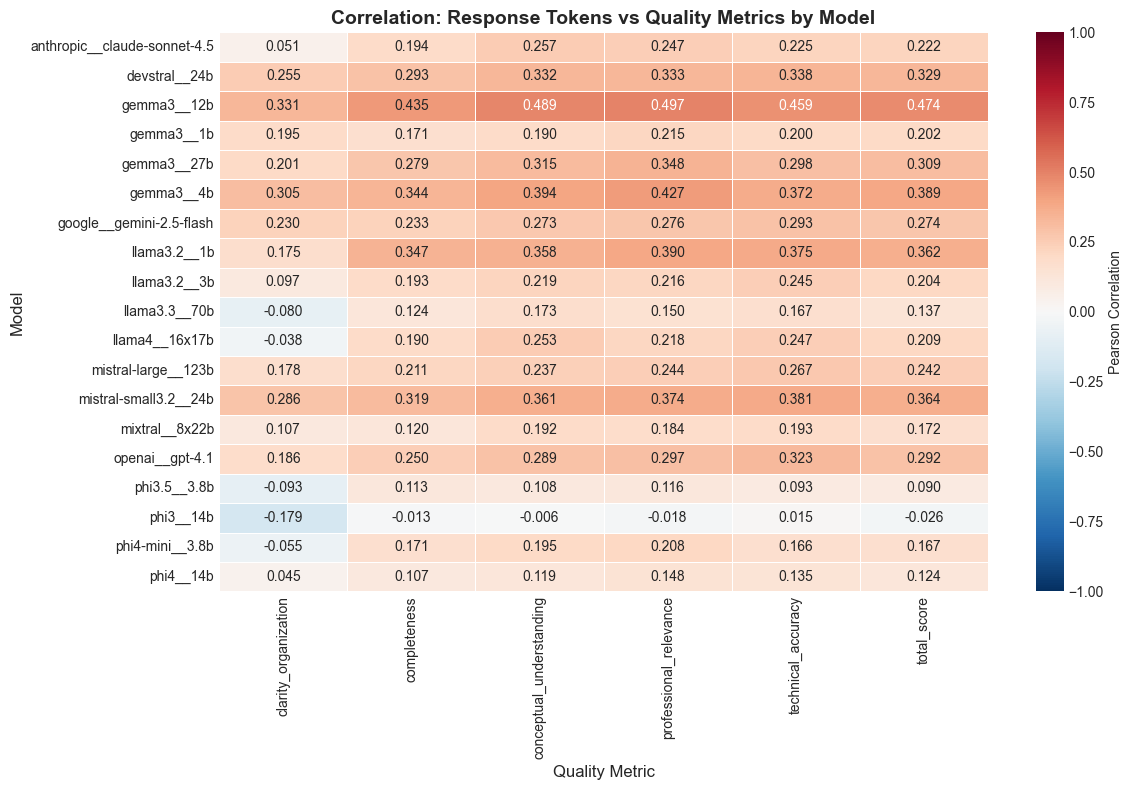

✅ Saved to output\token_quality_correlation.png
✅ Saved to output\token_quality_correlations.csv

Token-Quality Correlations (Pearson):
quality_metric                clarity_organization  completeness  \
model                                                              
anthropic__claude-sonnet-4.5                0.0513        0.1939   
devstral__24b                               0.2554        0.2928   
gemma3__12b                                 0.3305        0.4350   
gemma3__1b                                  0.1950        0.1712   
gemma3__27b                                 0.2013        0.2791   
gemma3__4b                                  0.3053        0.3437   
google__gemini-2.5-flash                    0.2304        0.2325   
llama3.2__1b                                0.1749        0.3474   
llama3.2__3b                                0.0971        0.1925   
llama3.3__70b                              -0.0804        0.1241   
llama4__16x17b                             -0.03

In [16]:
# Calculate correlations between token counts and quality metrics
quality_metrics = [
    'total_score',
    'technical_accuracy',
    'conceptual_understanding',
    'completeness',
    'clarity_organization',
    'professional_relevance'
]

correlation_results = []

for model in osq_df_filtered['model'].unique():
    model_data = osq_df_filtered[osq_df_filtered['model'] == model]
    
    for metric in quality_metrics:
        # Pearson correlation
        pearson_r, pearson_p = pearsonr(model_data['response_tokens'], model_data[metric])
        
        # Spearman correlation
        spearman_r, spearman_p = spearmanr(model_data['response_tokens'], model_data[metric])
        
        correlation_results.append({
            'model': model,
            'quality_metric': metric,
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
            'n_samples': len(model_data)
        })

correlation_df = pd.DataFrame(correlation_results)
correlation_df = correlation_df.round(4)

# Pivot for better visualization
correlation_pivot = correlation_df.pivot_table(
    index='model',
    columns='quality_metric',
    values='pearson_r'
)

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    correlation_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation'},
    linewidths=0.5
)
ax.set_title('Correlation: Response Tokens vs Quality Metrics by Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Quality Metric', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig(output_dir / 'token_quality_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {output_dir / 'token_quality_correlation.png'}")

# Save detailed correlation results
correlation_df.to_csv(output_dir / 'token_quality_correlations.csv', index=False)
print(f"✅ Saved to {output_dir / 'token_quality_correlations.csv'}")

print("\nToken-Quality Correlations (Pearson):")
print(correlation_pivot)

## Summary Statistics Table

In [17]:
# Comprehensive summary table
summary_table = osq_df_filtered.groupby('model').agg({
    'question_id': 'count',
    'response_tokens': ['mean', 'median', 'std'],
    'total_score': ['mean', 'median', 'std'],
    'score_per_token': ['mean', 'median'],
    'tokens_per_point': ['mean', 'median'],
    'total_cost': ['mean', 'sum']
}).round(3)

summary_table.columns = ['_'.join(col).strip() for col in summary_table.columns.values]
summary_table = summary_table.rename(columns={'question_id_count': 'n_samples'})

print("\n" + "="*80)
print("TOKENOMICS SUMMARY BY MODEL")
print("="*80)
print(summary_table)
print("\n")

# Save summary
summary_table.to_csv(output_dir / 'tokenomics_summary.csv')
print(f"✅ Saved to {output_dir / 'tokenomics_summary.csv'}")


TOKENOMICS SUMMARY BY MODEL
                              n_samples  response_tokens_mean  \
model                                                           
anthropic__claude-sonnet-4.5        841                48.609   
devstral__24b                       844                45.468   
gemma3__12b                         844                63.850   
gemma3__1b                          843                72.968   
gemma3__27b                         845                72.499   
gemma3__4b                          842                66.856   
google__gemini-2.5-flash            845                43.981   
llama3.2__1b                        845                61.727   
llama3.2__3b                        845                43.063   
llama3.3__70b                       845                56.479   
llama4__16x17b                      845                46.637   
mistral-large__123b                 836                49.691   
mistral-small3.2__24b               841                45.049

## Key Findings

This cell generates a markdown summary of key findings.

In [18]:
# Generate key findings
findings = []

# Most efficient model (score per token)
best_efficiency = token_stats_by_model.sort_values('score_per_token_mean', ascending=False).index[0]
findings.append(f"**Most Efficient Model**: {best_efficiency} (highest score per token)")

# Most verbose model
most_verbose = token_stats_by_model.sort_values('response_tokens_mean', ascending=False).index[0]
most_verbose_tokens = token_stats_by_model.loc[most_verbose, 'response_tokens_mean']
findings.append(f"**Most Verbose Model**: {most_verbose} ({most_verbose_tokens:.0f} avg tokens)")

# Most concise model
most_concise = token_stats_by_model.sort_values('response_tokens_mean').index[0]
most_concise_tokens = token_stats_by_model.loc[most_concise, 'response_tokens_mean']
findings.append(f"**Most Concise Model**: {most_concise} ({most_concise_tokens:.0f} avg tokens)")

# Best cost-effectiveness
best_cost = cost_quality_by_model.sort_values('cost_per_point').iloc[0]
findings.append(f"**Best Cost-Effectiveness**: {best_cost['model']} (${best_cost['cost_per_point']:.6f} per score point)")

# Overall correlation
overall_corr, _ = pearsonr(osq_df_filtered['response_tokens'], osq_df_filtered['total_score'])
correlation_direction = "positive" if overall_corr > 0 else "negative"
findings.append(f"**Overall Token-Quality Correlation**: {overall_corr:.3f} ({correlation_direction})")

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
for finding in findings:
    print(f"• {finding}")
print("\n")

# Save findings to file
with open(output_dir / 'tokenomics_findings.txt', 'w') as f:
    f.write("TOKENOMICS ANALYSIS - KEY FINDINGS\n")
    f.write("=" * 80 + "\n\n")
    for finding in findings:
        f.write(f"• {finding}\n")

print(f"✅ Saved to {output_dir / 'tokenomics_findings.txt'}")


KEY FINDINGS
• **Most Efficient Model**: google__gemini-2.5-flash (highest score per token)
• **Most Verbose Model**: phi3.5__3.8b (92 avg tokens)
• **Most Concise Model**: llama3.2__3b (43 avg tokens)
• **Best Cost-Effectiveness**: google__gemini-2.5-flash ($0.000006 per score point)
• **Overall Token-Quality Correlation**: 0.172 (positive)


✅ Saved to output\tokenomics_findings.txt


## Export Enhanced Dataset

Save the OSQ dataframe with all token metrics added.

In [ ]:
# Save enhanced dataset
osq_df_filtered.to_csv(output_dir / 'tokenomics_enhanced_dataset.csv', index=False)
print(f"✅ Saved enhanced dataset to {output_dir / 'tokenomics_enhanced_dataset.csv'}")
print(f"   Shape: {osq_df_filtered.shape}")
print(f"   New columns: prompt_tokens, response_tokens, expected_tokens, total_tokens, ")
print(f"                score_per_token, tokens_per_point, input_cost, output_cost, total_cost")

## Notebook Complete

All tokenomics analysis visualizations and data exports are complete.

### Output Files Generated:

1. `token_stats_by_model.csv` - Aggregate token statistics
2. `tokenomics_distribution.png` - Token distribution plots
3. `tokenomics_efficiency_scatter.png` - Efficiency scatter matrix
4. `tokenomics_budget_heatmap.png` - Token budget heatmaps
5. `tokenomics_cost_quality.png` - Cost-quality bubble chart
6. `tokenomics_length_vs_quality.png` - Token length vs quality bars
7. `token_quality_correlation.png` - Correlation heatmap
8. `token_quality_correlations.csv` - Detailed correlation data
9. `tokenomics_summary.csv` - Comprehensive summary table
10. `tokenomics_findings.txt` - Key findings summary
11. `tokenomics_enhanced_dataset.csv` - Enhanced dataset with token metrics